# Cloud Service Providers: Transformation & Analytics

This notebook mirrors the approach used in the data cleaning phase. We will process each transformation scenario (T01-T20) step-by-step. Let's load the cleaned dataset first.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Apply styling
plt.style.use('ggplot')
sns.set_palette('viridis')

# 1. Load the Cleaned Dataset
df = pd.read_csv('data/cleaned/cleaned_usage_billing.csv')
df.head(3)


,Usage_ID,Account_ID,Timestamp,Service,SKU,Usage_Value,Unit,Cost,Currency,FX_Rate,...,Dept_Clean,Project_Clean,Is_Unknown_Dept,Is_Unknown_Project,Is_Invalid_Combo,SLA_Event_Clean,SLA_Messy_Flag,SLA_Event_Clean_Str,Log_Skew_Clean,Is_High_Skew
0,U00523,AZ-ACCT-025,2026/01/27 16:26,Database,SQLDb-S2,24647.80,minutes,€758.64,EUR,1.080,...,HR,GAMMA,False,False,False,False,True,False,57.7,False
1,U05552,AZ-ACCT-027,2026-03-07T08:53:00Z,Storage,blob-hot,880.15,Gb,$60.37,dollar,1.000,...,UNKNOWN_DEPT,PHOENIX,True,False,False,False,True,False,89.9,True
2,U09485,GCP-ACCT-044,2026-03-10T13:11:00-05:00,Compute,GCE-n1-standard-4,6182.58,hrs,180.15,inr,0.012,...,OPERATIONS,DELTA,False,False,False,False,True,False,93.7,True


## T01: Daily Cost & Usage Cubes
**Transformation Code (`transforms/t01_cost_usage_cubes.py`)** extracts a normalized daily and monthly aggregation of Spend & Usage (by Service, SKU, Region).


In [2]:
from transforms.t01_cost_usage_cubes import run as t01_run

# Execute the transformation logic on the dataframe
df_t01_daily, df_t01_monthly = t01_run(df)
df_t01_daily.head()


✅ T01 — Cost & Usage Cubes generated
   Daily Cube Rows:   5600
   Monthly Cube Rows: 420


,Date,Service_Clean,SKU_Clean,Region_Clean,Total_Cost_USD,Total_Usage,Log_Count
0,2025-12-31,Database,SQLDb-S2,canadacentral,36.01416,3.106625e+04,1
1,2025-12-31,Storage,Blob-Hot,eastus,37.53000,4.512000e-01,1
2,2026-01-01,Compute,EC2-t3.large,ap-south-1,507.93360,8.983003e+04,3
3,2026-01-01,Compute,EC2-t3.large,ap-southeast-1,867.51000,1.144684e+08,1
4,2026-01-01,Compute,EC2-t3.large,eu-west-1,2.88000,1.243300e+02,1


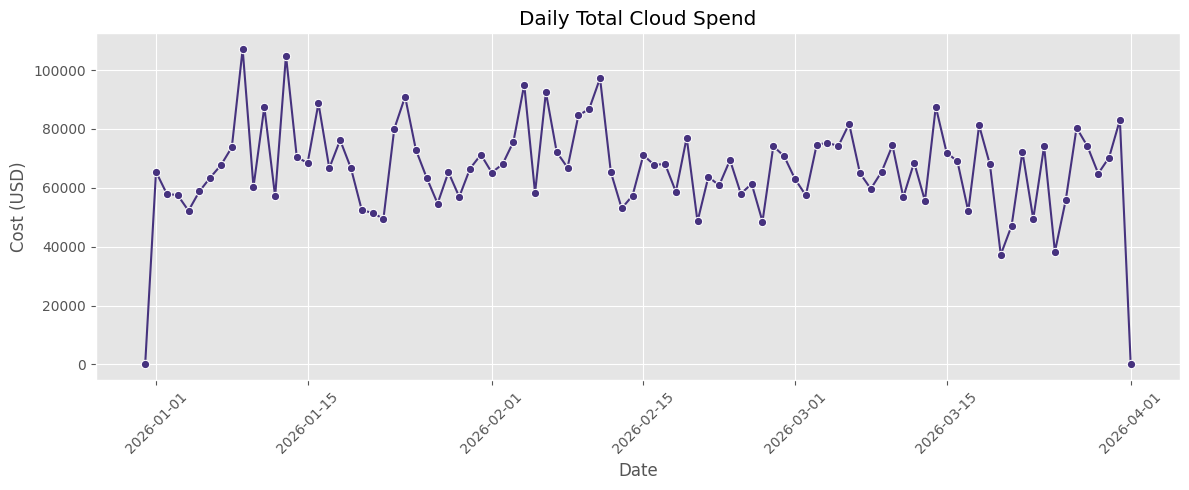

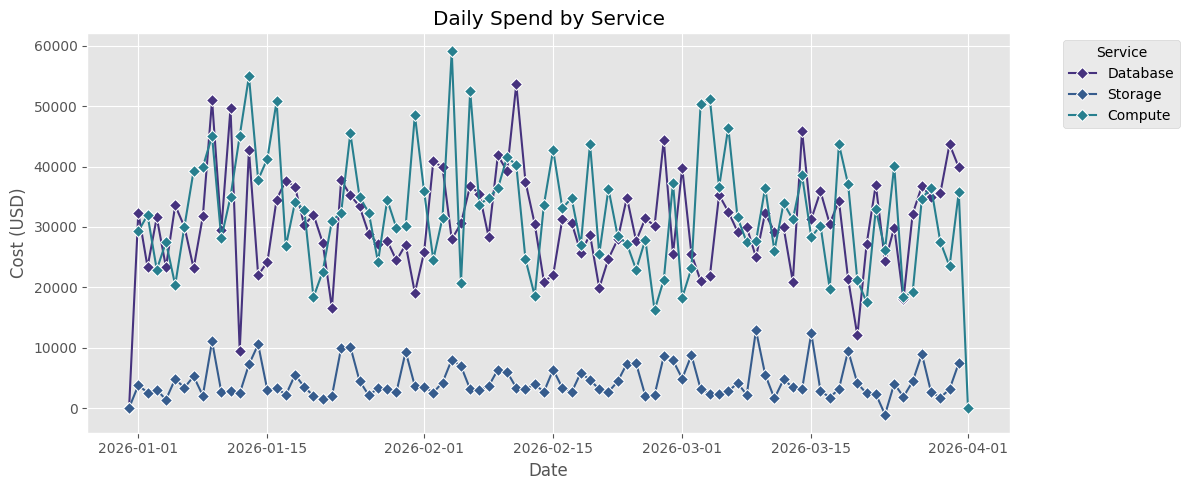

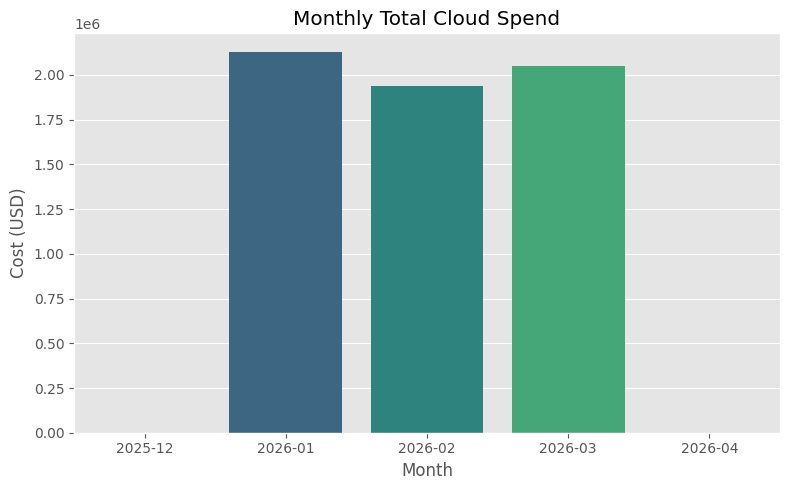

In [3]:
# Graphing T01 Output
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert date for plotting
df_t01_daily['Date'] = pd.to_datetime(df_t01_daily['Date'])

# Overall Spend Trend
trend = df_t01_daily.groupby('Date')['Total_Cost_USD'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=trend, x='Date', y='Total_Cost_USD', marker='o')
plt.title('Daily Total Cloud Spend')
plt.xlabel('Date')
plt.ylabel('Cost (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Spend by Service (Daily)
svc_trend = df_t01_daily.groupby(['Date', 'Service_Clean'])['Total_Cost_USD'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=svc_trend, x='Date', y='Total_Cost_USD', hue='Service_Clean', marker='D')
plt.title('Daily Spend by Service')
plt.xlabel('Date')
plt.ylabel('Cost (USD)')
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Spend by Month (Bar Chart)
month_trend = df_t01_monthly.groupby('Month')['Total_Cost_USD'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=month_trend, x='Month', y='Total_Cost_USD', palette='viridis')
plt.title('Monthly Total Cloud Spend')
plt.xlabel('Month')
plt.ylabel('Cost (USD)')
plt.tight_layout()
plt.show()


## T02: Chargeback & Showback
**Transformation Code (`transforms/t02_chargeback.py`)** aggregates Total Cost by Department and Project for internal billing.


In [4]:
from transforms.t02_chargeback import run as t02_run

df_t02 = t02_run(df)
df_t02.head()


✅ T02 — Chargeback Table generated
   Total Departments: 11
   Total Projects:    9


,Dept_Clean,Project_Clean,Total_Cost_USD,Record_Count
38,HR,DELTA,307080.26694,489
83,SECURITY,DELTA,304291.33874,469
60,MARKETING,OMEGA,303959.29778,504
78,PRODUCT,OMEGA,294926.87278,476
48,LEGAL,EPSILON,287992.57542,434


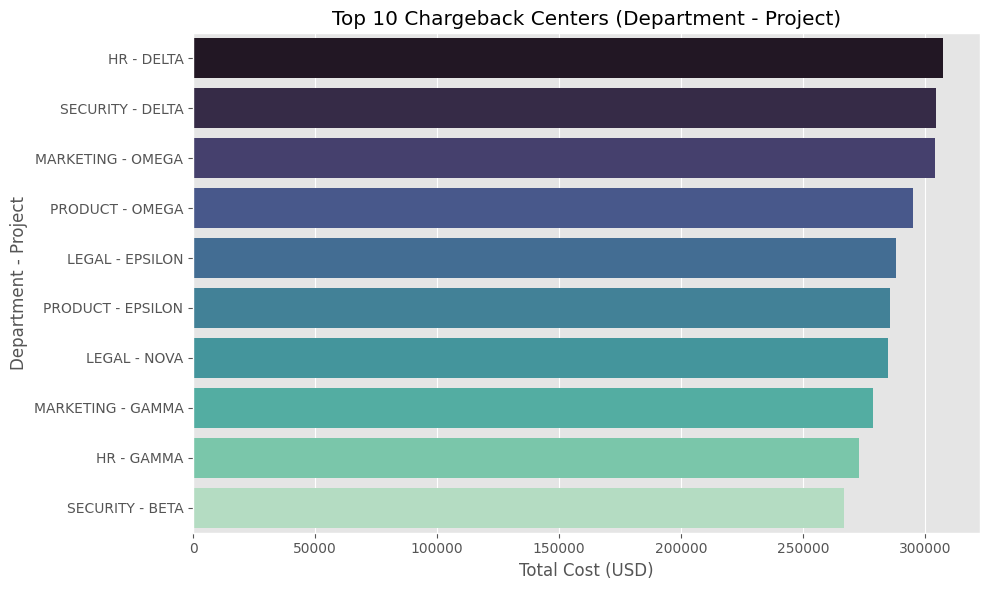

In [5]:
# Graphing T02 Output
top_cb = df_t02.head(10).copy()
plt.figure(figsize=(10, 6))
top_cb['Dept_Project'] = top_cb['Dept_Clean'] + " - " + top_cb['Project_Clean']
sns.barplot(data=top_cb, x='Total_Cost_USD', y='Dept_Project', hue='Dept_Project', legend=False, palette='mako')
plt.title('Top 10 Chargeback Centers (Department - Project)')
plt.xlabel('Total Cost (USD)')
plt.ylabel('Department - Project')
plt.tight_layout()
plt.show()


## T03: RI/SP Utilization
**Transformation Code (`transforms/t03_ri_utilization.py`)** calculates the ratio of Cost structured as 'reserved' vs 'on-demand' vs 'spot'.


In [6]:
from transforms.t03_ri_utilization import run as t03_run

df_t03 = t03_run(df)
df_t03


✅ T03 — RI/SP Utilization generated
   Reserved Coverage: 34.32%


,Purchase_Type_Clean,Total_Cost_USD,Record_Count,Cost_Percentage
0,on-demand,3.148081e+06,5238,48.97
1,reserved,2.206508e+06,3565,34.32
2,spot,1.073869e+06,1747,16.70


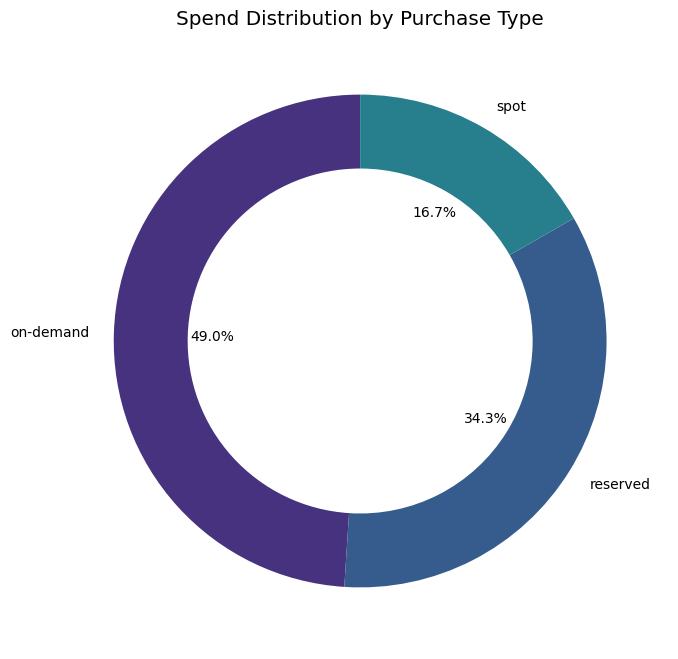

In [7]:
# Graphing T03 Output
plt.figure(figsize=(8, 8))
plt.pie(df_t03['Cost_Percentage'], labels=df_t03['Purchase_Type_Clean'], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Spend Distribution by Purchase Type')
plt.show()
